In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()  # Load environment variables from .env file

True

In [3]:
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

c:\ML-DL\AgenticAI-LangGraph\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [5]:
def create_outline(state: BlogState) -> BlogState:
    title = state["title"]
    prompt = f"Create an outline for a blog post with the title: {title}"
    outline = model.invoke(prompt).content
    state["outline"] = outline
    return state

In [6]:
def create_blog(state: BlogState) -> BlogState:
    title = state["title"]
    outline = state["outline"]
    prompt = f"Write a blog post with the title: {title} and the following outline: {outline}"
    content = model.invoke(prompt).content
    state["content"] = content
    return state

In [7]:
graph=StateGraph(BlogState)

graph.add_node("create_outline",create_outline)
graph.add_node("create_blog",create_blog)

graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)

workflow=graph.compile()

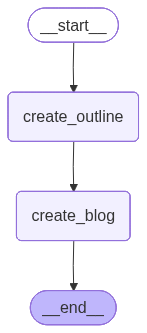

In [8]:
workflow

In [9]:
initial_state={'title': 'The Future of AI in Healthcare'}
final_state=workflow.invoke(initial_state)
print(final_state)

{'title': 'The Future of AI in Healthcare', 'outline': 'Certainly! Here’s an outline for a blog post titled "The Future of AI in Healthcare":\n\n---\n\n**Title: The Future of AI in Healthcare**\n\n**Introduction**\n- Brief introduction to AI in healthcare\n- Importance of AI in enhancing healthcare delivery\n- Thesis statement: The integration of AI in healthcare will revolutionize patient care, diagnostics, and treatment, leading to more personalized and efficient healthcare systems.\n\n**Section 1: Current Applications of AI in Healthcare**\n- **Diagnosis and Early Detection**\n  - Explanation of AI algorithms and machine learning techniques used in identifying diseases\n  - Examples like AI in detecting cancer through imaging, diagnosing cardiovascular diseases, and predicting patient risks\n- **Medical Imaging Analysis**\n  - How AI enhances the accuracy of radiology, ophthalmology, and other imaging techniques\n  - Case studies of successful AI applications in medical imaging\n- *

In [10]:
print(final_state['outline'])

Certainly! Here’s an outline for a blog post titled "The Future of AI in Healthcare":

---

**Title: The Future of AI in Healthcare**

**Introduction**
- Brief introduction to AI in healthcare
- Importance of AI in enhancing healthcare delivery
- Thesis statement: The integration of AI in healthcare will revolutionize patient care, diagnostics, and treatment, leading to more personalized and efficient healthcare systems.

**Section 1: Current Applications of AI in Healthcare**
- **Diagnosis and Early Detection**
  - Explanation of AI algorithms and machine learning techniques used in identifying diseases
  - Examples like AI in detecting cancer through imaging, diagnosing cardiovascular diseases, and predicting patient risks
- **Medical Imaging Analysis**
  - How AI enhances the accuracy of radiology, ophthalmology, and other imaging techniques
  - Case studies of successful AI applications in medical imaging
- **Drug Discovery and Development**
  - Role of AI in accelerating drug disc

In [11]:
print(final_state['content'])

# The Future of AI in Healthcare

The integration of artificial intelligence (AI) in healthcare is a rapidly evolving field that promises to revolutionize patient care, diagnostics, and treatment. As technology advances, AI is becoming an indispensable tool in enhancing the efficiency and effectiveness of healthcare systems. In this blog post, we will explore the current applications of AI in healthcare, emerging technologies, future trends, and the ethical considerations that come with these advancements.

## Introduction

Artificial intelligence has been transforming various industries, and healthcare is no exception. By leveraging machine learning, natural language processing, and other advanced techniques, AI is helping healthcare providers deliver more personalized and efficient care. The integration of AI in healthcare will not only enhance diagnostic accuracy but also improve patient outcomes and reduce healthcare costs.

The thesis of this article is that the integration of AI 